Primero vamos a ver cómo funciona todo con la implementación ya hecha en python, con la librería PyWavelets.

In [ ]:
!pip install PyWavelets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 34.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

Creamos una señal de prueba con ruido.

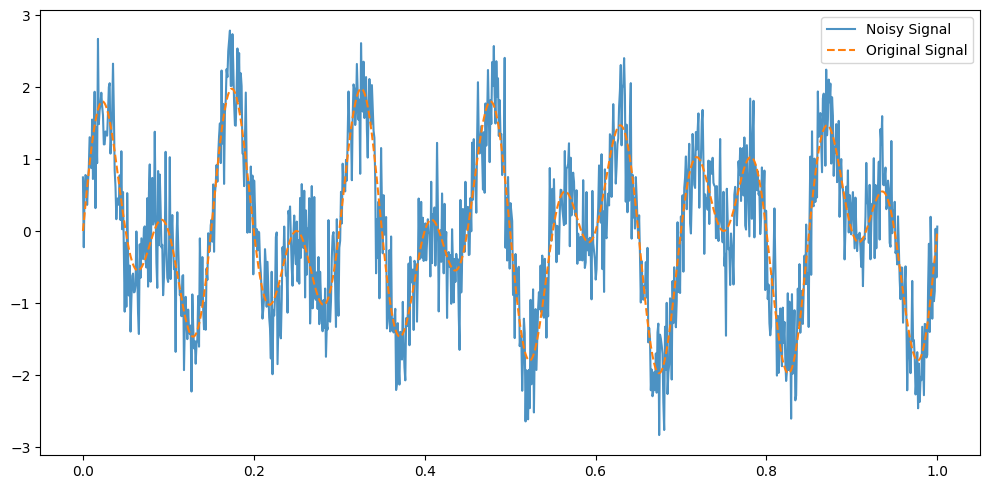

In [ ]:
x = np.linspace(0, 1, 1024) #resolución de 1024
signal = np.sin(2 * np.pi * 7 * x) + np.sin(2 * np.pi * 13 * x)
noise = np.random.normal(0, 0.5, x.shape)
noisy_signal = signal + noise

plt.figure(figsize=(10, 5))
plt.plot(x, noisy_signal, label='Noisy Signal', alpha=0.8)
plt.plot(x, signal, label='Original Signal', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

Ahora vamos a crer la función que nos da la señal eliminando el ruido, y veremos si se aproxima a la señan sinuoidal inicial.

Primero voy a explicar la descomposición por niveles. La idea es, a partir de la señal, obtener los n coeficientes de aproximación a1 y detalle d1. A continuación aplicamos lo mismo a a1, obteniendo n/2 coeficientes de aproximación a2 y detalle d2, así iterativamente hasta alcanzar el nivel que busquemos. En el pdf que pasé se explica esto con la wavelet de haar. Ingrid lo explica en la sección 5.6

Así, si por ejemplo queremos llegar al nivel 4, tendremos a4, d4, d3, d2, d1, donde en di hay $\frac{n}{2^{i-1}}$ coeficientes.

Usamos las siguientes funciones:

pywt.wavedec: le pasamos la señal con ruido, el tipo de wavelet que queremos usar y el nivel al que queremos llegar, y nos devuelve los coeficientes de aproximación [0] y los de detalle [1:end].

pywt.threshold: le pasamos los coeficientes de detalle y el valor umbral, y quita (en modo hard) o reduce (en modo soft) aquellos coeficientes menores que el umbral. CAMBIO: EL UMBRAL ES ADAPTATIVO PARA PODER QUITAR BIEN RUIDO BLANCO

pywt.waverec: le pasamos los coeficientes ya pasados por el filtro y el tipo de wavelet que habíamos usado, para que nos reconstruya la señal esta vez ya sin el ruido.

He usado la wavelet 'db4' porque me la ha dado ChatGPT

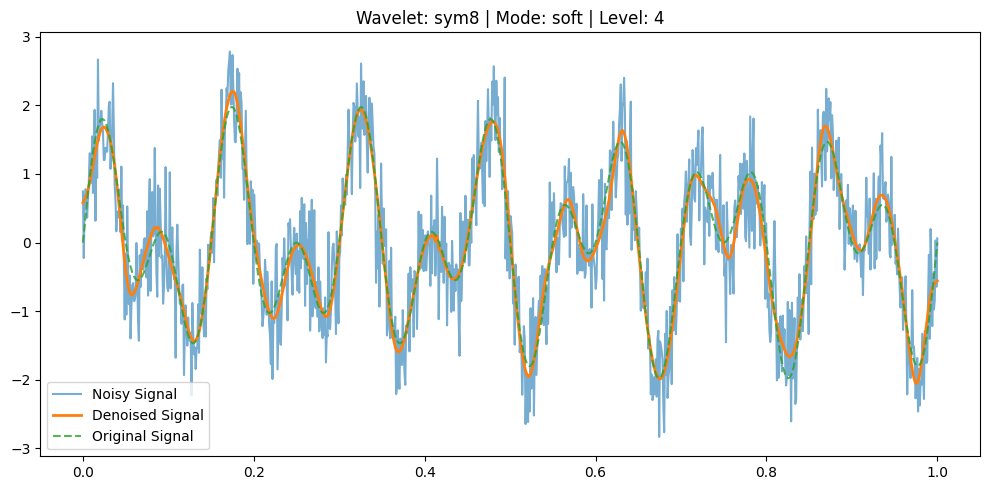

array([ 0.58128106,  0.60173333,  0.62549659, ..., -0.57630538,
       -0.56571804, -0.55754658])

In [ ]:
def wavelet_denoising(threshold=0.7, wavelet_name='db4', mode='soft', level=4):
    coeffs = pywt.wavedec(noisy_signal, wavelet=wavelet_name, level=level) #es un array de arrays, cada array son los coeficientes [a4, d4, d3, d2, d1]
    coeffs_thresh = [coeffs[0]]  # añadimos los coeficientes de aproximación, esos no se tocan
    for d in coeffs[1:]:
        coeffs_thresh.append(pywt.threshold(detail, threshold, mode=mode)) # vamos añadiendo al array los arrays de detalle pasados por el filtro

    denoised_signal = pywt.waverec(coeffs_thresh, wavelet=wavelet_name) # reconstruimos la señan sin ruido
    denoised_signal = denoised_signal[:len(signal)] # para poder graficar

    plt.figure(figsize=(10, 5))
    plt.plot(x, noisy_signal, label='Noisy Signal', alpha=0.6)
    plt.plot(x, denoised_signal, label='Denoised Signal', linewidth=2)
    plt.plot(x, signal, label='Original Signal', linestyle='--', alpha=0.8)
    plt.title(f"Wavelet: {wavelet_name} | Mode: {mode} | Level: {level}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return denoised_signal

wavelet_denoising(threshold=0.3, wavelet_name='sym8', mode='soft', level=4) #no usa haar, haar es db1 creo, pero db4 lo hace mejor

¡Éxito! Ahora la idea es crear esas 3 funciones por nosotros mismos. Me basaré en el capítulo 5 del libro de Ingrid, el cual solo he leido muy por encima jejeje así que esperemos poder ligar esto con la teoria fácilente.

Pero bueno el tema es tenemos dos bases ortonormales de L2. Una formada por traslaciones y dilataciones de la función madre (la wavelet), y otra formada por traslaciones y dilataciones de la función padre (llamada también función de escala).

Voy a hacer mi implementación con Haar.

Función padre:
$$\phi(t) =
\begin{cases}
1, & 0 \leq t < 1 \\
0, & \text{en otro caso}
\end{cases}
$$

Función madre:
$$\psi(t) =
\begin{cases}
1, & 0 \leq t < \frac{1}{2} \\
-1, & \frac{1}{2} \leq t < 1 \\
0, & \text{en otro caso}
\end{cases}
$$

Ecuaciones de refinamiento
$$\phi(t) = \sum_{n} h[n] \sqrt{2} \, \phi(2t - n)$$
$$\psi(t) = \sum_{n} g[n] \sqrt{2} \, \phi(2t - n)$$

Solución de las ecuaciones
$$h[0] = \frac{1}{\sqrt{2}}, \quad h[1] = \frac{1}{\sqrt{2}} \Rightarrow h = \left[ \frac{1}{\sqrt{2}}, \frac{1}{\sqrt{2}} \right]
$$
$$
g[0] = \frac{1}{\sqrt{2}}, \quad g[1] = -\frac{1}{\sqrt{2}} \Rightarrow g = \left[ \frac{1}{\sqrt{2}}, -\frac{1}{\sqrt{2}} \right]
$$

Si $n \neq 0,1$ entonces h[n] y g[n] vale 0.




In [ ]:
h = np.array([ 1 / np.sqrt(2),  1 / np.sqrt(2)])      # (escala)
g = np.array([ 1 / np.sqrt(2), - 1 / np.sqrt(2)])     # (detalle)

g y h es lo que hay que convolucionar (convolución discreta) con la señal para obtener los coeficientes. Notamos que al convolucionar obtenemos el mismo número cada dos números del array (esto significa que perdemos resolución, aunque no perdemos información porque aunque haya la mitad de resolución, tenemos el doble en coeficientes), así que solo hay que guardar la mitad de los numeritos (lo que se llama submuestrear, que en código es poner [::2] al final del array).

In [ ]:
def myWavedec(signal, level): #para que esto no tenga problema con la longitud de los arrays, usamos resolución potencia alta de 2
  coeffs = []
  current_signal = signal
  for _ in range(level):
    approx = np.convolve(current_signal, h, mode='same')[::2]
    detail = np.convolve(current_signal, g, mode='same')[::2]

    coeffs.insert(0, detail)
    current_signal = approx

  coeffs.insert(0, current_signal)
  return coeffs

La función de filtrado la haré solo en modo duro, básicamente haré 0 todos los coeficientes más bajos que el umbral.

In [ ]:
def myThreshold(data, threshold):
    data = np.asarray(data)
    result = data.copy()
    result[np.abs(data) < threshold] = 0
    return result

Por último haré la función que reconstruye la señal. El método se basa en la transformada discreta de wavelets inversa (IDWT). Para reconstruir nivel a nivel se usa la siguiente ecuación:
$$
a_{j-1}[n] = \sum_k h[k - 2n] \cdot a_j[k] + \sum_k g[k - 2n] \cdot d_j[k]
$$
Observamos que para obtener los coeficientes de un nivel inferior hay que hacer 2 convoluciones discretas.

h y g son las mismas de antes para haar, creo que es porque es ortogonal o algo así, en otras wavelets se necesitan h y g distintas para reconstruir


NOTA: No encuentro esta ecuación en el libro de Ingrid :(

Para que el array $a_{j-1}$ tenga la longitud que toca, vamos a upsamplear, es decir, al array $a_j$ le vamos a intercalar 0 entre todos sus valores para que tenga el doble de longitud.

In [ ]:
def upsample(signal):
    """
    Intercala ceros entre muestras (upsample por 2).
    """
    up = np.zeros(len(signal) * 2)
    up[::2] = signal
    return up

def myWaverec(coeffs):
    """
    Reconstruye la señal original a partir de [a_n, d_n, ..., d_1]
    usando wavelet Haar.
    """

    a = coeffs[0]  # a_n
    for d in coeffs[1:]:
        a_up = upsample(a)
        d_up = upsample(d)

        a_conv = np.convolve(a_up, h, mode='same')
        d_conv = np.convolve(d_up, g, mode='same')

        a = a_conv + d_conv

        # a = a_conv[:min(len(a_conv), len(d_conv))] + d_conv[:min(len(a_conv), len(d_conv))]
        # lo de :min(len(a_conv), len(d_conv)) es porque el np.convolve puede hacer que el array tenga más longitud de la que toca
        # no se si aqui pierdo información, quizás si
    return a

Veamos si funciona todo esto.

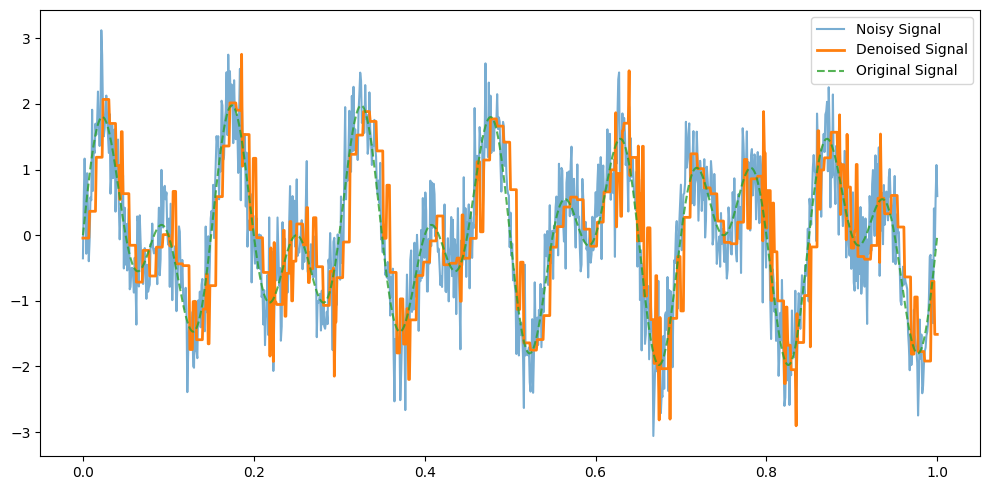

In [ ]:
def myWavelet_denoising(threshold=1):
    coeffs = myWavedec(noisy_signal, 3)
    coeffs_thresh = [coeffs[0]]
    for detail in coeffs[1:]:
        coeffs_thresh.append(myThreshold(detail, threshold))
    denoised_signal = myWaverec(coeffs_thresh)

    denoised_signal=denoised_signal[:len(signal)]

    plt.figure(figsize=(10, 5))
    plt.plot(x, noisy_signal, label='Noisy Signal', alpha=0.6)
    plt.plot(x, denoised_signal, label='Denoised Signal', linewidth=2)
    plt.plot(x, signal, label='Original Signal', linestyle='--', alpha=0.8)
    plt.legend()
    plt.tight_layout()
    plt.show()

myWavelet_denoising()

No tanto éxito, pero vamos bien encaminados. se ve que la wavelet de haar no es demasiado buena filtrando ruido. Creo que si encontramos la wavelet adecuada, podríamos tener buenos resulatdos con esta implementación.

He usado una resolución potencia de 2 para no tener problemas con la longitud de los arrays, porque al convolucionar y tal pasan cosas que no controlo muy bien, eso habrá que tenerlo en cuenta. ACUTALIZACIÓN: Ahora si controlo bien esto, leete la teoria detenidamente para saber qué pasa (que los coefs son 0 infinitamente a izquierda y derecha) y si te lias me dices



Vamos a usar PyWavelets para el audio de Rafa. (lo explico todo peor)


Primero, cambio la función para ponerle un umbral móvil, lo que hace que se quita mejor el ruido en los silencios, creo

In [ ]:
def wavelet_denoising(threshold=0.7, wavelet_name='db4', mode='soft', level=4):
    coeffs = pywt.wavedec(noisy_signal, wavelet=wavelet_name, level=level) #es un array de arrays, cada array son los coeficientes [a4, d4, d3, d2, d1]
    coeffs_thresh = [coeffs[0]]  # añadimos los coeficientes de aproximación, esos no se tocan
    for d in coeffs[1:]:
        sigma = np.median(np.abs(d)) / 0.6745
        threshold = sigma * np.sqrt(2 * np.log(len(d)))
        coeffs_thresh.append(pywt.threshold(d, threshold, mode=mode))

    denoised_signal = pywt.waverec(coeffs_thresh, wavelet=wavelet_name) # reconstruimos la señan sin ruido
    denoised_signal = denoised_signal[:len(signal)] # para poder graficar

    plt.figure(figsize=(10, 5))
    plt.plot(x, noisy_signal, label='Noisy Signal', alpha=0.6)
    plt.plot(x, denoised_signal, label='Denoised Signal', linewidth=2)
    plt.plot(x, signal, label='Original Signal', linestyle='--', alpha=0.8)
    plt.title(f"Wavelet: {wavelet_name} | Threshold: {threshold} | Mode: {mode} | Level: {level}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return denoised_signal

In [ ]:
# prompt: transforma el archivo rafa.ogg en una señal que pueda manipular con PyWavelets

import librosa

# Cargar el archivo de audio
audio_file = 'rafa.ogg'  # Reemplaza con la ruta correcta a tu archivo
try:
    y, sr = librosa.load(audio_file)
except FileNotFoundError:
    print(f"Error: El archivo '{audio_file}' no fue encontrado.")
    exit()

# Ahora 'y' contiene la señal de audio como un array de NumPy, y 'sr' la frecuencia de muestreo.
# Puedes usar 'y' directamente con PyWavelets para realizar la denoising.

# 'y' contiene toda la señal y 'sr' es la frecuencia de muestreo
signal = y

# Crear un eje temporal basado en la duración del audio
x = np.linspace(0, len(signal) / sr, len(signal))



In [ ]:
from scipy.signal import butter, lfilter

def highpass_gaussian_noise(signal_shape, cutoff_freq, sampling_rate, order=5):
    """
    Genera ruido blanco gaussiano y aplica un filtro paso alto.

    Args:
        signal_shape (tuple): Forma del array de la señal original.
        cutoff_freq (float): Frecuencia de corte del filtro paso alto en Hz.
        sampling_rate (float): Frecuencia de muestreo de la señal en Hz.
        order (int): Orden del filtro Butterworth.

    Returns:
        numpy.ndarray: Ruido gaussiano filtrado con atenuación en las frecuencias graves.
    """
    # Generar ruido blanco gaussiano
    noise = np.random.normal(0, 1.0, signal_shape)

    # Diseñar el filtro paso alto Butterworth
    nyquist_freq = 0.5 * sampling_rate
    normalized_cutoff = cutoff_freq / nyquist_freq
    b, a = butter(order, normalized_cutoff, btype='high', analog=False)

    # Aplicar el filtro al ruido
    filtered_noise = lfilter(b, a, noise)

    return filtered_noise

# Ejemplo de uso:
sampling_rate = 44100  # Frecuencia de muestreo típica para audio
cutoff_frequency = 2000 # Frecuencia de corte en Hz (ajusta este valor)
signal_shape = signal.shape # Asumiendo que 'signal' ya está definido

noise = highpass_gaussian_noise(signal_shape, cutoff_frequency, sampling_rate)

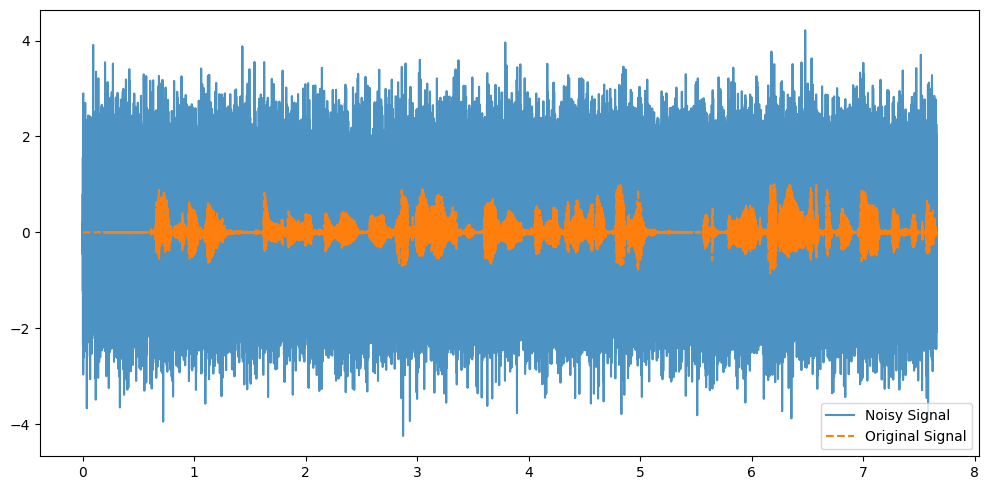

In [ ]:
#noise = np.random.normal(0, 0.4, signal.shape)  # ruido blanco, bajo nivel
noisy_signal = signal + noise

plt.figure(figsize=(10, 5))
plt.plot(x, noisy_signal, label='Noisy Signal', alpha=0.8)
plt.plot(x, signal, label='Original Signal', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

Recuperamos el audio con el ruido.

In [ ]:
!pip install soundfile


In [ ]:
import soundfile as sf

# Guardar la señal con ruido en formato OGG
output_file = 'rafa_noisy.ogg'
sf.write(output_file, noisy_signal, sr, format='OGG', subtype='VORBIS')

print(f"Archivo guardado como: {output_file}")

Archivo guardado como: rafa_noisy.ogg


Ahora hacemos el denoising (mismo código que antes)

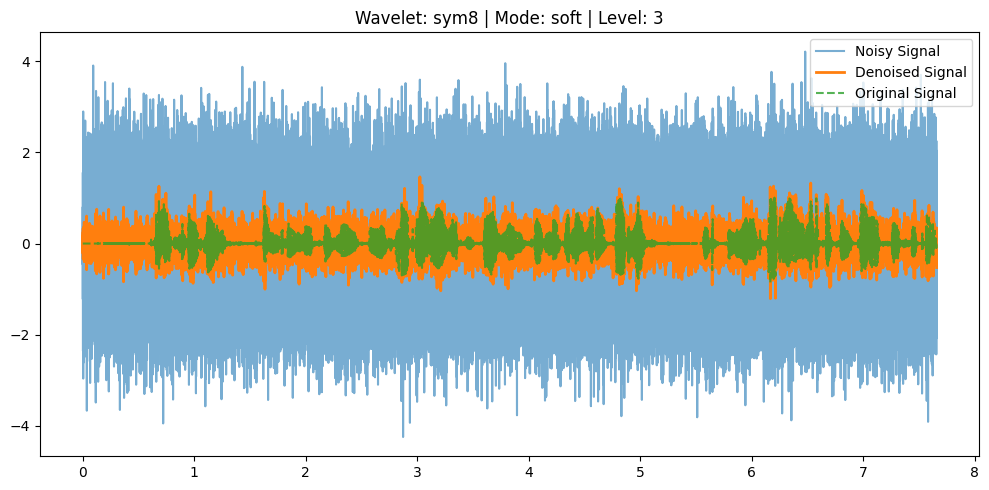

Archivo guardado como: rafa_denoised.ogg


In [ ]:
denoised_signal = wavelet_denoising(threshold=0.3, wavelet_name='sym8', mode='soft', level=3)

# Guardar la señal con ruido en formato OGG
output_file = 'rafa_denoised.ogg'
sf.write(output_file, denoised_signal, sr, format='OGG', subtype='VORBIS')

print(f"Archivo guardado como: {output_file}")

In [ ]:
wavelet = pywt.Wavelet('sym8')

# Filtros de descomposición (análisis)
dec_lo = wavelet.dec_lo
dec_hi = wavelet.dec_hi

# Filtros de reconstrucción (síntesis)
rec_lo = wavelet.rec_lo
rec_hi = wavelet.rec_hi

print("Filtro Paso Bajo de Descomposición (dec_lo):", np.array(dec_lo))
print("Filtro Paso Alto de Descomposición (dec_hi):", np.array(dec_hi))
print("Filtro Paso Bajo de Reconstrucción (rec_lo):", np.array(rec_lo))
print("Filtro Paso Alto de Reconstrucción (rec_hi):", np.array(rec_hi))

Filtro Paso Bajo de Descomposición (dec_lo): [-3.38241595e-03 -5.42132332e-04  3.16950878e-02  7.60748732e-03
 -1.43294238e-01 -6.12733591e-02  4.81359651e-01  7.77185752e-01
  3.64441895e-01 -5.19458381e-02 -2.72190299e-02  4.91371797e-02
  3.80875201e-03 -1.49522583e-02 -3.02920515e-04  1.88995033e-03]
Filtro Paso Alto de Descomposición (dec_hi): [-1.88995033e-03 -3.02920515e-04  1.49522583e-02  3.80875201e-03
 -4.91371797e-02 -2.72190299e-02  5.19458381e-02  3.64441895e-01
 -7.77185752e-01  4.81359651e-01  6.12733591e-02 -1.43294238e-01
 -7.60748732e-03  3.16950878e-02  5.42132332e-04 -3.38241595e-03]
Filtro Paso Bajo de Reconstrucción (rec_lo): [ 1.88995033e-03 -3.02920515e-04 -1.49522583e-02  3.80875201e-03
  4.91371797e-02 -2.72190299e-02 -5.19458381e-02  3.64441895e-01
  7.77185752e-01  4.81359651e-01 -6.12733591e-02 -1.43294238e-01
  7.60748732e-03  3.16950878e-02 -5.42132332e-04 -3.38241595e-03]
Filtro Paso Alto de Reconstrucción (rec_hi): [-3.38241595e-03  5.42132332e-04  3.1

Cosas para las diapos:


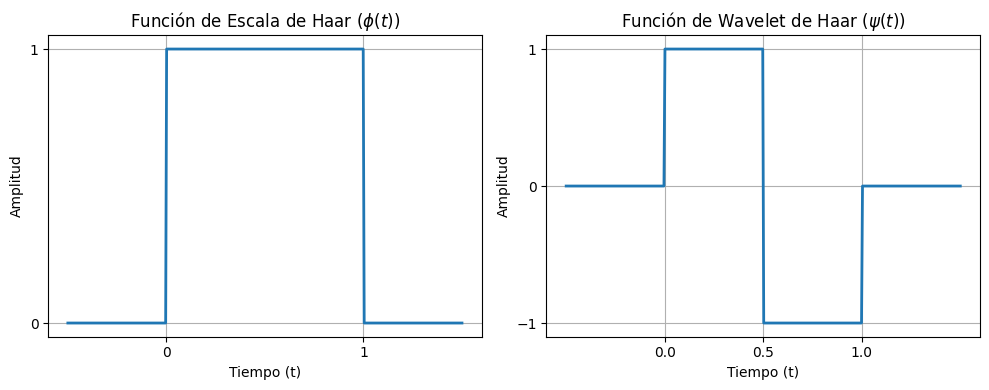

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de la función de escala de Haar
def phi(t):
    if 0 <= t < 1:
        return 1
    else:
        return 0

# Definición de la función de wavelet de Haar
def psi(t):
    if 0 <= t < 0.5:
        return 1
    elif 0.5 <= t < 1:
        return -1
    else:
        return 0

# Generar puntos para graficar
t_phi = np.linspace(-0.5, 1.5, 400)
phi_values = [phi(t) for t in t_phi]

t_psi = np.linspace(-0.5, 1.5, 400)
psi_values = [psi(t) for t in t_psi]

# Graficar la función de escala
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t_phi, phi_values, linewidth=2)
plt.title('Función de Escala de Haar ($\phi(t)$)')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.xticks([0, 1])
plt.yticks([0, 1])

# Graficar la función de wavelet
plt.subplot(1, 2, 2)
plt.plot(t_psi, psi_values, linewidth=2)
plt.title('Función de Wavelet de Haar ($\psi(t)$)')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.xticks([0, 0.5, 1])
plt.yticks([-1, 0, 1])

plt.tight_layout()
plt.show()